# 3. Input grids: bathymetry and wind

**What this shows:** how rompy-swan turns datasets into SWAN input grids, with the
bathymetry from Tutorial 1 and hourly ERA5 winds, and a wind-sea run.

**Prerequisites:** [2. The computational grid and spectrum](02_grid_and_spectrum.ipynb).

**You will learn:**

- the difference between the computational grid and SWAN's input grids
- how `SwanDataGrid` selects, converts and writes bathymetry and wind
- why time-varying inputs need SWAN's nonstationary mode, and how to make a
  stationary computation at a given time
- which other input grids SWAN accepts

**Data used:** `etopo15s_perth.nc` (ETOPO 2022 bathymetry) and `era5-20230101.nc`
(hourly ERA5 winds at 10 m on 1 January 2023).

## Setup

In [1]:
import shutil
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from pydantic import ValidationError
from rompy.logging import config as logging_config

logging_config.update(level="WARNING")

DATA_DIR = Path("../data")
OUT_DIR = Path("_output") / "03_input_grids"
shutil.rmtree(OUT_DIR, ignore_errors=True)
OUT_DIR.mkdir(parents=True)

## 1. Computational and input grids

SWAN computes on the computational grid, but reads bathymetry, wind, currents and
other fields on their own *input grids*, which it interpolates to the computational
grid. Each input grid is declared with an `INPGRID` command and read with `READINP`.
Input grids should cover the whole computational grid: outside them, SWAN extends
depths from the nearest edge and sets wind and currents to zero.

In rompy-swan, a `SwanDataGrid` writes both commands and the data file from a
dataset. It crops the data to the computational grid, plus a `buffer`, and to the run
period.

In [2]:
from rompy.core.time import TimeRange
from rompy_swan.grid import SwanGrid

grid = SwanGrid(x0=114.5, y0=-32.8, dx=0.02, dy=0.02, nx=71, ny=66)
period = TimeRange(start="2023-01-01T15:00", end="2023-01-01T16:00", interval="1h")

## 2. Bathymetry

The bathymetry is the `bottom` variable. Here the data is on its own 15″ grid, about
four times finer than the computational grid. `z1` names the variable in the
dataset, and `fac=-1` turns elevations (positive up) into depths (positive down), as
SWAN expects. `get()` writes the data file and returns the commands.

In [3]:
from rompy.core.source import SourceFile
from rompy_swan.data import SwanDataGrid

bottom = SwanDataGrid(
    var="bottom",
    source=SourceFile(uri=DATA_DIR / "etopo15s_perth.nc"),
    z1="z",
    fac=-1.0,
    coords={"x": "longitude", "y": "latitude"},
    buffer=0.1,
)
print(bottom.get(OUT_DIR, grid=grid, time=period))

INPGRID BOTTOM REG 114.402083333 -32.8979166667 0.0 383 359 0.00416666666667 0.00416666666667 EXC 99.0
READINP BOTTOM -1.0 'bottom.grd' 3 FREE



`INPGRID BOTTOM REG` gives the corner, rotation, number of meshes and spacing of the
input grid, and `EXC` the exception value that marks missing data. `READINP` gives
`fac`, the file name and its layout. The selected data is also available as an xarray
dataset, cropped to the grid and buffer:

In [4]:
bottom.ds

<xarray.Dataset> Size: 559kB
Dimensions:    (latitude: 360, longitude: 384)
Coordinates:
  * latitude   (latitude) float64 3kB -32.9 -32.89 -32.89 ... -31.41 -31.4
  * longitude  (longitude) float64 3kB 114.4 114.4 114.4 ... 116.0 116.0 116.0
Data variables:
    z          (latitude, longitude) float32 553kB ...
Attributes: (12/34)
    cdm_data_type:                  Grid
    Conventions:                    CF-1.10, COARDS, ACDD-1.3
    creator_email:                  dem.info@noaa.gov
    creator_name:                   National Centers for Environmental Inform...
    creator_type:                   Institution
    creator_url:                    https://www.ngdc.noaa.gov/mgg/bathymetry/...
    ...                             ...
    sourceUrl:                      (local files)
    Southernmost_Northing:          -33.99791666666667
    standard_name_vocabulary:       CF Standard Name Table v70
    summary:                        ETOPO 2022 is a 15 arc-second global reli...
    title:                          ETOPO_2022_v1_15s
    Westernmost_Easting:            114.00208333333333

## 3. Wind

Wind is a vector, so it needs two variables: `z1` and `z2` are the eastward and
northward components. Two details of this ERA5 file matter:

- its latitudes run north to south, and a `Filter` sorts them so the data can be
  cropped;
- its 0.25° grid is coarse compared with the model, so a larger `buffer` makes sure
  the wind covers the whole domain.

In [5]:
from rompy.core.filters import Filter

wind = SwanDataGrid(
    var="wind",
    source=SourceFile(uri=DATA_DIR / "era5-20230101.nc"),
    z1="u10",
    z2="v10",
    coords={"x": "longitude", "y": "latitude"},
    filter=Filter(sort={"coords": ["latitude"]}),
    buffer=0.25,
)
print(wind.get(OUT_DIR, grid=grid, time=period))

INPGRID WIND REG 114.25 -33.0 0.0 7 7 0.25 0.25 EXC -99.0 NONSTATION 20230101.150000 1.00 HR
READINP WIND 1.0 'wind.grd' 3 0 1 0 FREE



The wind changes with time, so `INPGRID WIND` is `NONSTATIONARY`: it gives the first
time and the interval, and the file holds one block of data per time. Here are the
winds at 15:00, a typical afternoon sea breeze from the south-south-west:

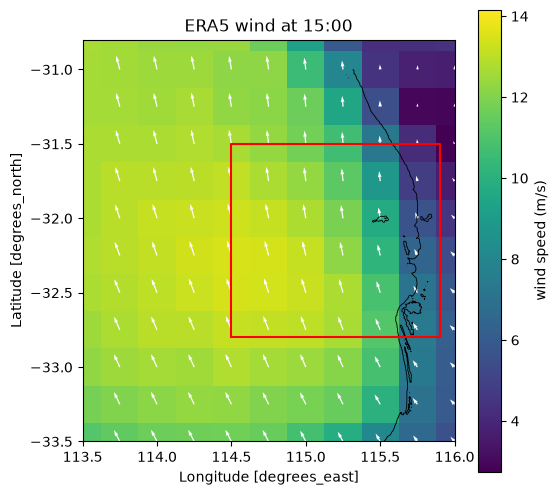

In [6]:
era5 = xr.open_dataset(DATA_DIR / "era5-20230101.nc").sel(time="2023-01-01T15:00")
etopo = xr.open_dataset(DATA_DIR / "etopo15s_perth.nc")
fig, ax = plt.subplots(figsize=(6, 6))
np.hypot(era5.u10, era5.v10).plot(ax=ax, cmap="viridis", cbar_kwargs={"label": "wind speed (m/s)"})
ax.quiver(era5.longitude, era5.latitude, era5.u10, era5.v10, color="w")
etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.6)
x0, y0, x1, y1 = grid.bbox()
ax.plot([x0, x1, x1, x0, x0], [y0, y0, y1, y1, y0], "r")
ax.set(xlim=(113.5, 116), ylim=(-33.5, -30.8), title="ERA5 wind at 15:00")
ax.set_aspect("equal");

## 4. Time-varying input and the SWAN mode

`DataInterface` groups the input grids of a model: the `bottom` and a list of other
`input` grids.

In [7]:
from rompy_swan.interface import DataInterface

inpgrid = DataInterface(bottom=bottom, input=[wind])

SWAN runs in stationary mode unless told otherwise, and in stationary mode it accepts
no time information: not in the inputs, not in the computation. rompy-swan checks
this when the configuration is created:

In [8]:
from rompy_swan.components.cgrid import REGULAR
from rompy_swan.config import SwanConfig
from rompy_swan.subcomponents.spectrum import SPECTRUM

cgrid = REGULAR(grid=grid.component, spectrum=SPECTRUM(mdc=36, flow=0.04, fhigh=1.0))
try:
    SwanConfig(cgrid=cgrid, inpgrid=inpgrid)
except ValidationError as err:
    print(err)

1 validation error for SwanConfig
  Value error, SWAN does not accept time information, used by the wind input, in stationary mode (MODE STATIONARY is the default). Set startup.mode=MODE(kind='nonstationary') for computations at given times (COMPUTE_STAT or COMPUTE_NONSTAT) and time-varying inputs. [type=value_error, input_value={'cgrid': REGULAR(model_t...ND: 'wind'>, fac=1.0)])}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


`MODE NONSTATIONARY` allows time-varying inputs. The computation can still be
stationary: `COMPUTE_STAT` computes the wave field in equilibrium with the conditions
at one moment, the start of the run period. [Tutorial 6](06_nonstationary_hindcast.ipynb)
runs a nonstationary computation over a whole day.

In [9]:
from rompy_swan.components.group import LOCKUP, OUTPUT, PHYSICS, STARTUP
from rompy_swan.components.lockup import COMPUTE_STAT
from rompy_swan.components.output import BLOCK
from rompy_swan.components.physics import GEN3
from rompy_swan.components.startup import COORDINATES, MODE, PROJECT, SET
from rompy_swan.subcomponents.startup import SPHERICAL

config = SwanConfig(
    startup=STARTUP(
        project=PROJECT(name="Wind sea", nr="t03"),
        set=SET(direction_convention="nautical"),
        mode=MODE(kind="nonstationary"),
        coordinates=COORDINATES(kind=SPHERICAL()),
    ),
    cgrid=cgrid,
    inpgrid=inpgrid,
    physics=PHYSICS(gen=GEN3()),
    output=OUTPUT(
        block=BLOCK(
            sname="COMPGRID", fname="swangrid.nc", output=["hsign", "dir", "tps", "wind"]
        )
    ),
    lockup=LOCKUP(compute=COMPUTE_STAT()),
)

## 5. A wind-sea run

There is no wave boundary in this model: every wave is generated by the wind inside
the domain.

In [10]:
from rompy.backends import DockerConfig
from rompy.model import ModelRun

modelrun = ModelRun(run_id="wind_sea", period=period, output_dir=OUT_DIR, config=config)
workspace = Path(modelrun())
input_file = (workspace / "INPUT").read_text()
print("\n".join(line for line in input_file.splitlines() if line and line[0] != "!"))

PROJECT name='Wind sea' nr='t03'
SET NAUTICAL
MODE NONSTATIONARY TWODIMENSIONAL
COORDINATES SPHERICAL CCM
CGRID REGULAR xpc=114.5 ypc=-32.8 alpc=0.0 xlenc=1.4 ylenc=1.3 mxc=70 myc=65 CIRCLE mdc=36 flow=0.04 fhigh=1.0
INPGRID BOTTOM REG 114.402083333 -32.8979166667 0.0 383 359 0.00416666666667 0.00416666666667 EXC 99.0
READINP BOTTOM -1.0 'bottom.grd' 3 FREE
INPGRID WIND REG 114.25 -33.0 0.0 7 7 0.25 0.25 EXC -99.0 NONSTATION 20230101.150000 1.00 HR
READINP WIND 1.0 'wind.grd' 3 0 1 0 FREE
GEN3 WESTHUYSEN DRAG WU
BLOCK sname='COMPGRID' fname='swangrid.nc' &
    HSIGN &
    DIR &
    TPS &
    WIND &
    OUTPUT tbegblk=20230101.150000 deltblk=3600.0 SEC
COMPUTE STATIONARY time=20230101.150000
STOP


In [11]:
def docker_available() -> bool:
    """Return True if the Docker daemon can be reached."""
    try:
        return subprocess.run(["docker", "info"], capture_output=True).returncode == 0
    except FileNotFoundError:
        return False


if docker_available():
    backend = DockerConfig(image="ghcr.io/rom-py/swan:41.51", executable="swan.exe")
    ok = modelrun.run(backend, workspace_dir=workspace)
    print("SWAN finished successfully" if ok else "SWAN failed, see PRINT")
else:
    print("Docker is not available, skipping the model run")

SWAN finished successfully


The waves grow with the distance the wind has blown over the water (the fetch), so
they are smallest along the southern boundary and in the lee of the coast and
islands.

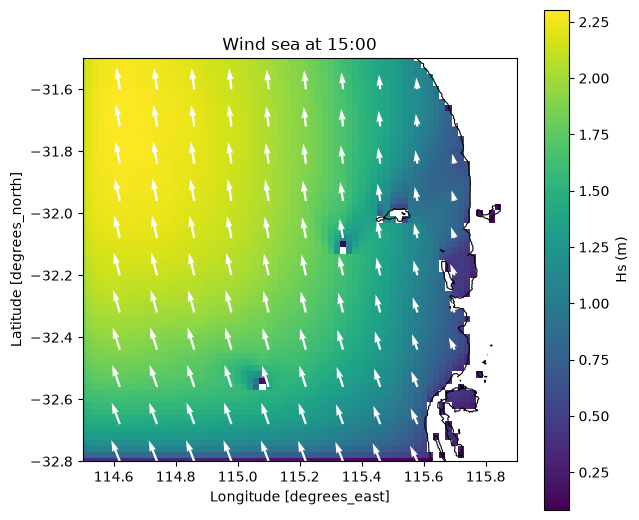

In [12]:
outfile = workspace / "swangrid.nc"
if outfile.exists():
    ds = xr.open_dataset(outfile).isel(time=0)
    fig, ax = plt.subplots(figsize=(7, 6.5))
    ds.hs.plot(ax=ax, cmap="viridis", cbar_kwargs={"label": "Hs (m)"})
    etopo.z.plot.contour(ax=ax, levels=[0], colors="k", linewidths=0.8)
    step = ds.isel(longitude=slice(None, None, 6), latitude=slice(None, None, 6))
    ax.quiver(step.longitude, step.latitude, step.xwnd, step.ywnd, color="w", scale=250)
    ax.set(xlim=(114.5, 115.9), ylim=(-32.8, -31.5), title="Wind sea at 15:00")
    ax.set_aspect("equal")

## 6. Other input grids

The same pattern reads the other fields SWAN accepts. The main ones are:

| `var` | Field | Variables |
|---|---|---|
| `bottom` | Bathymetry | `z1` (use `fac=-1` for elevation) |
| `wind` | Wind at 10 m | `z1`, `z2`: eastward and northward components |
| `current` | Currents | `z1`, `z2`: eastward and northward components |
| `wlevel` | Water level | `z1` |
| `friction` | Bottom friction coefficient | `z1` |
| `aice`, `hice` | Sea ice concentration and thickness | `z1` |

[Input grids](../examples/input_grids.ipynb) shows them, together with other data
sources and the options to select data.

## Summary

- SWAN reads fields on input grids that it interpolates to the computational grid.
- `SwanDataGrid` crops a dataset to the grid and period, converts it with `fac`, and
  writes `INPGRID`/`READINP` and the data file.
- Time-varying inputs need `MODE NONSTATIONARY`; `COMPUTE_STAT` then computes a
  stationary wave field at the start of the period.

**Next:** [4. Wave boundaries](04_wave_boundaries.ipynb).